# Residual Learning for Quadrotor Control
## Stage 1: 6-DOF Quadrotor Dynamics Simulator

This notebook implements a full 6 degree-of-freedom (6-DOF) rigid body quadrotor simulator from scratch.

Model:

- 3 translational DOF: x, y, z position in the world frame
- 3 rotational DOF: roll (φ), pitch (θ), yaw (ψ) using ZYX Euler angles
- Newton-Euler equations of motion
- Rotor thrust and torque physics


End goal:

1. A `Quadrotor` class that simulates physically accurate drone dynamics
2. A working gravity-only free-fall test
3. A hover thrust test (drone suspended in air)
4. 3D trajectory visualizations

---

## 1. Imports & Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

print("Imports OK.")

Imports OK.


## 2. Quadrotor Physical Parameters

We model a realistic 250mm-class racing/research quadrotor (similar to a DJI Phantom scale).

Main vars:

- `m` — total mass (kg)
- `I` — inertia tensor (kg·m²), diagonal for a symmetric quad
- `l` — arm length from center to rotor (m)
- `kf` — thrust coefficient: F = kf * ω²
- `km` — torque coefficient: τ = km * ω²
- `max_rpm` — motor saturation limit

In [ ]:
# ── Physical constants ──────────────────────────────────────────────────────
g = 9.81  # gravitational acceleration (m/s^2)

# ── Quadrotor parameters (250mm class) ─────────────────────────────────────
PARAMS = {
    'm'       : 0.5,                                  # mass (kg)
    'I'       : np.diag([4.9e-3, 4.9e-3, 8.8e-3]),  # inertia tensor (kg·m%2)
    'l'       : 0.175,                                # arm length (m)
    'kf'      : 2.0e-6,                               # thrust coefficient (N·s^2/rad^2)
    'km'      : 5.0e-9,                               # torque coefficient (N·m·s^2/rad^2)
    'max_rpm' : 8000.0,                               # max rotor speed (RPM)
    'g'       : g,
}

# Derived: hover RPM — the RPM each rotor needs to exactly cancel gravity
# 4 * kf * omega_hover^2 = m * g  =>  omega_hover = sqrt(mg / 4kf)
omega_hover = np.sqrt(PARAMS['m'] * g / (4 * PARAMS['kf']))  # rad/s
rpm_hover   = omega_hover * 60 / (2 * np.pi)

print(f"Hover rotor speed : {omega_hover:.1f} rad/s  ({rpm_hover:.0f} RPM)")
print(f"Max rotor speed   : {PARAMS['max_rpm']:.0f} RPM")
print(f"Hover is {rpm_hover/PARAMS['max_rpm']*100:.1f}% of max throttle — physically reasonable.")

Hover rotor speed : 783.0 rad/s  (7477 RPM)
Max rotor speed   : 8000 RPM
Hover is 93.5% of max throttle — physically reasonable.


## 3. Rotation Utilities

We use **ZYX Euler angles** (yaw → pitch → roll) which is what they use in real engineering

In [ ]:
def rotation_matrix(phi, theta, psi):
    """
    ZYX Euler angle rotation matrix: body frame -> world frame.
    phi   = roll  (rotation about x)
    theta = pitch (rotation about y)
    psi   = yaw   (rotation about z)
    """
    cphi, sphi     = np.cos(phi),   np.sin(phi)
    cth,  sth      = np.cos(theta), np.sin(theta)
    cpsi, spsi     = np.cos(psi),   np.sin(psi)

    # Individual axis rotations
    Rx = np.array([[1,    0,     0   ],
                   [0,    cphi, -sphi],
                   [0,    sphi,  cphi]])

    Ry = np.array([[ cth,  0,  sth],
                   [ 0,    1,  0  ],
                   [-sth,  0,  cth]])

    Rz = np.array([[cpsi, -spsi, 0],
                   [spsi,  cpsi, 0],
                   [0,     0,   1]])

    return Rz @ Ry @ Rx


def euler_rate_matrix(phi, theta):
    """
    Transforms body-frame angular velocities (p,q,r) to Euler angle rates.
    Inverse of the standard W matrix.
    Note: singular at theta = ±90° (gimbal lock) — avoided in normal flight.
    """
    cphi, sphi = np.cos(phi), np.sin(phi)
    cth,  sth  = np.cos(theta), np.sin(theta)
    tth        = np.tan(theta)

    return np.array([[1, sphi*tth,  cphi*tth],
                     [0, cphi,     -sphi    ],
                     [0, sphi/cth,  cphi/cth]])


# Quick sanity check: R should be orthogonal (R^T R = I)
R_test = rotation_matrix(0.1, 0.2, 0.3)
error  = np.max(np.abs(R_test.T @ R_test - np.eye(3)))
print(f"Rotation matrix orthogonality error: {error:.2e}  (should be ~1e-16)")

Rotation matrix orthogonality error: 2.22e-16  (should be ~1e-16)


## 4. Equations of Motion

```
      1 (CCW)
      |
4 ---[+]--- 2 (CW)
      |
      3 (CCW)
```
Rotors 1,3 spin counter-clockwise; 2,4 spin clockwise.

In [ ]:
class Quadrotor:
    """
    6-DOF quadrotor rigid body simulator.

    State vector (12-dim):
        [0:3]  position        (x, y, z)         world frame, meters
        [3:6]  velocity        (xdot, ydot, zdot) world frame, m/s
        [6:9]  euler angles    (phi, theta, psi)  roll, pitch, yaw, radians
        [9:12] body ang. vel.  (p, q, r)          body frame, rad/s

    Inputs (4-dim):
        rotor angular velocities [omega1, omega2, omega3, omega4] in rad/s
    """

    def __init__(self, params: dict):
        self.m   = params['m']
        self.I   = params['I']
        self.Iinv = np.linalg.inv(self.I)
        self.l   = params['l']
        self.kf  = params['kf']
        self.km  = params['km']
        self.g   = params['g']
        self.max_omega = params['max_rpm'] * 2 * np.pi / 60  # RPM -> rad/s

        # Rotor spin directions: +1 = CCW, -1 = CW
        # Layout:  1(CCW) front, 2(CW) right, 3(CCW) back, 4(CW) left
        self.spin_dirs = np.array([1, -1, 1, -1], dtype=float)

    def reset(self, state=None):
        """Reset to a given state or the default (hover position, level)."""
        if state is not None:
            self.state = state.copy()
        else:
            self.state = np.zeros(12)
            self.state[2] = 1.0  # start 1m above ground
        return self.state.copy()

    def _compute_forces_torques(self, omega_rotors, disturbance=None):
        """
        Compute total thrust force and body torques from rotor speeds.

        Args:
            omega_rotors: array of 4 rotor speeds (rad/s), will be clipped to [0, max]
            disturbance:  optional 3-vector of external force (world frame, Newtons)

        Returns:
            F_total : scalar thrust (N)
            tau     : 3-vector body torque [tau_phi, tau_theta, tau_psi] (N·m)
        """
        # Clip rotor speeds to physical limits
        omega = np.clip(omega_rotors, 0, self.max_omega)
        omega_sq = omega ** 2

        # Individual rotor thrusts
        F_rotors = self.kf * omega_sq   # shape (4,)

        # Total thrust (along body z-axis, pointing up)
        F_total = np.sum(F_rotors)

        # Torques in body frame
        # Roll  (phi):   rotor 4 (left) up, rotor 2 (right) up
        tau_phi   = self.l * (F_rotors[3] - F_rotors[1])
        # Pitch (theta): rotor 1 (front) up, rotor 3 (back) up
        tau_theta = self.l * (F_rotors[0] - F_rotors[2])
        # Yaw   (psi):   reaction torques from spin direction differences
        tau_psi   = self.km * np.sum(self.spin_dirs * omega_sq)

        tau = np.array([tau_phi, tau_theta, tau_psi])

        return F_total, tau

    def derivatives(self, state, omega_rotors, disturbance=None):
        """
        Compute state derivatives: xdot = f(x, u, d)

        This is the core of the simulator. Implements Newton-Euler equations.
        """
        # Unpack state
        pos    = state[0:3]   # position (world)
        vel    = state[3:6]   # velocity (world)
        angles = state[6:9]   # euler angles [phi, theta, psi]
        omega  = state[9:12]  # body angular velocity [p, q, r]

        phi, theta, psi = angles
        p,   q,     r   = omega

        # Rotation matrix: body -> world
        R = rotation_matrix(phi, theta, psi)

        # Forces and torques from rotors
        F_total, tau = self._compute_forces_torques(omega_rotors)

        # ── Translational dynamics ───────────────────────────────────────
        # Thrust force acts along body z-axis -> rotate to world frame
        thrust_world = R @ np.array([0, 0, F_total])

        # Gravity acts in world -z
        gravity_world = np.array([0, 0, -self.m * self.g])

        # External disturbance (wind, etc.)
        dist = disturbance if disturbance is not None else np.zeros(3)

        # Acceleration: F = ma
        acc = (thrust_world + gravity_world + dist) / self.m

        # ── Rotational dynamics ──────────────────────────────────────────
        # Euler's rotation equation: I*omega_dot = tau - omega x (I*omega)
        gyro_term   = np.cross(omega, self.I @ omega)
        omega_dot   = self.Iinv @ (tau - gyro_term)

        # Convert body angular velocity to Euler angle rates
        W_inv       = euler_rate_matrix(phi, theta)
        euler_dot   = W_inv @ omega

        # ── Pack derivatives ─────────────────────────────────────────────
        dstate = np.zeros(12)
        dstate[0:3]  = vel        # pos_dot  = velocity
        dstate[3:6]  = acc        # vel_dot  = acceleration
        dstate[6:9]  = euler_dot  # angle_dot
        dstate[9:12] = omega_dot  # omega_dot

        return dstate

    def step(self, omega_rotors, dt, disturbance=None):
        """
        Advance simulation by one timestep using RK4 integration.

        Args:
            omega_rotors: (4,) array of rotor speeds in rad/s
            dt:           timestep in seconds
            disturbance:  optional (3,) external force vector (world frame)

        Returns:
            new state (12,) array
        """
        x = self.state

        # RK4 integration
        k1 = self.derivatives(x,            omega_rotors, disturbance)
        k2 = self.derivatives(x + dt/2 * k1, omega_rotors, disturbance)
        k3 = self.derivatives(x + dt/2 * k2, omega_rotors, disturbance)
        k4 = self.derivatives(x + dt    * k3, omega_rotors, disturbance)

        self.state = x + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

        # Wrap yaw to [-pi, pi]
        self.state[8] = (self.state[8] + np.pi) % (2*np.pi) - np.pi

        return self.state.copy()


# Instantiate the simulator
quad = Quadrotor(PARAMS)
print("Quadrotor simulator instantiated successfully.")
print(f"State dimensions: {quad.reset().shape}")

Quadrotor simulator instantiated successfully.
State dimensions: (12,)


## 5. Test 1: Free-Fall

With zero rotor input, the drone should fall under gravity.
 Yhis checks if the physics are correct.

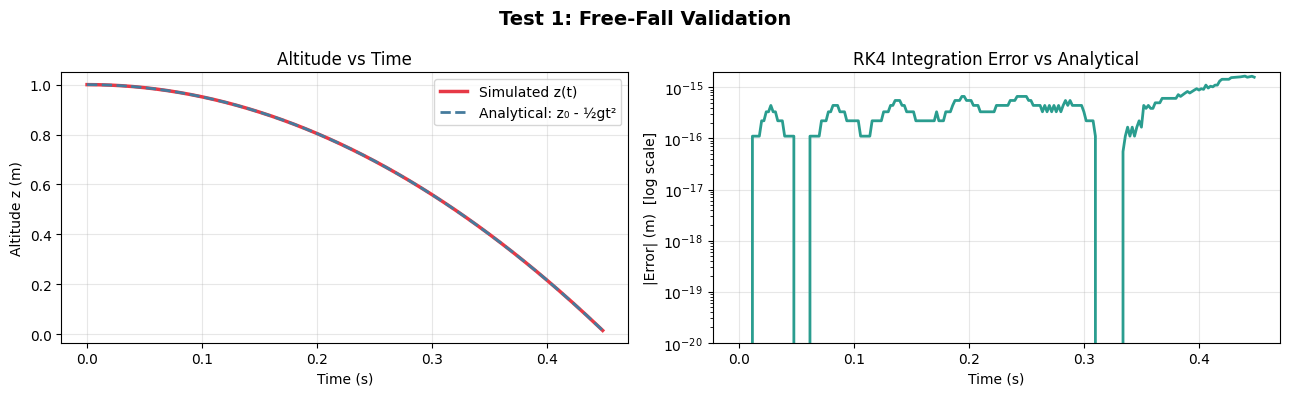

Max integration error: 1.67e-15 m  (RK4 is very accurate at dt=0.002s)


In [ ]:
# ── Simulation setup ────────────────────────────────────────────────────────
dt      = 0.002   # 500 Hz simulation rate (standard for quadrotor control)
t_end   = 0.45    # stop before hitting ground
t_span  = np.arange(0, t_end, dt)

quad.reset()   # start at [0,0,1] with zero velocity
z0 = quad.state[2]

# Zero rotor input = free fall
rotors_off = np.zeros(4)

states_ff = [quad.state.copy()]
for _ in t_span[1:]:
    quad.step(rotors_off, dt)
    states_ff.append(quad.state.copy())

states_ff = np.array(states_ff)

# Analytical solution
z_analytical = z0 - 0.5 * g * t_span**2

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Test 1: Free-Fall Validation', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(t_span, states_ff[:, 2],   color='#e63946', lw=2.5, label='Simulated z(t)')
ax.plot(t_span, z_analytical, '--', color='#457b9d', lw=2,   label='Analytical: z₀ - ½gt²')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Altitude z (m)')
ax.set_title('Altitude vs Time')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
error = np.abs(states_ff[:, 2] - z_analytical)
ax.semilogy(t_span, error, color='#2a9d8f', lw=2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('|Error| (m)  [log scale]')
ax.set_title('RK4 Integration Error vs Analytical')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=1e-20)

plt.tight_layout()
plt.savefig('freefall_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Max integration error: {error.max():.2e} m  (RK4 is very accurate at dt={dt}s)")

## 6. Test 2: Hover

Now we command each rotor to spin at exactly `omega_hover` rad/s.

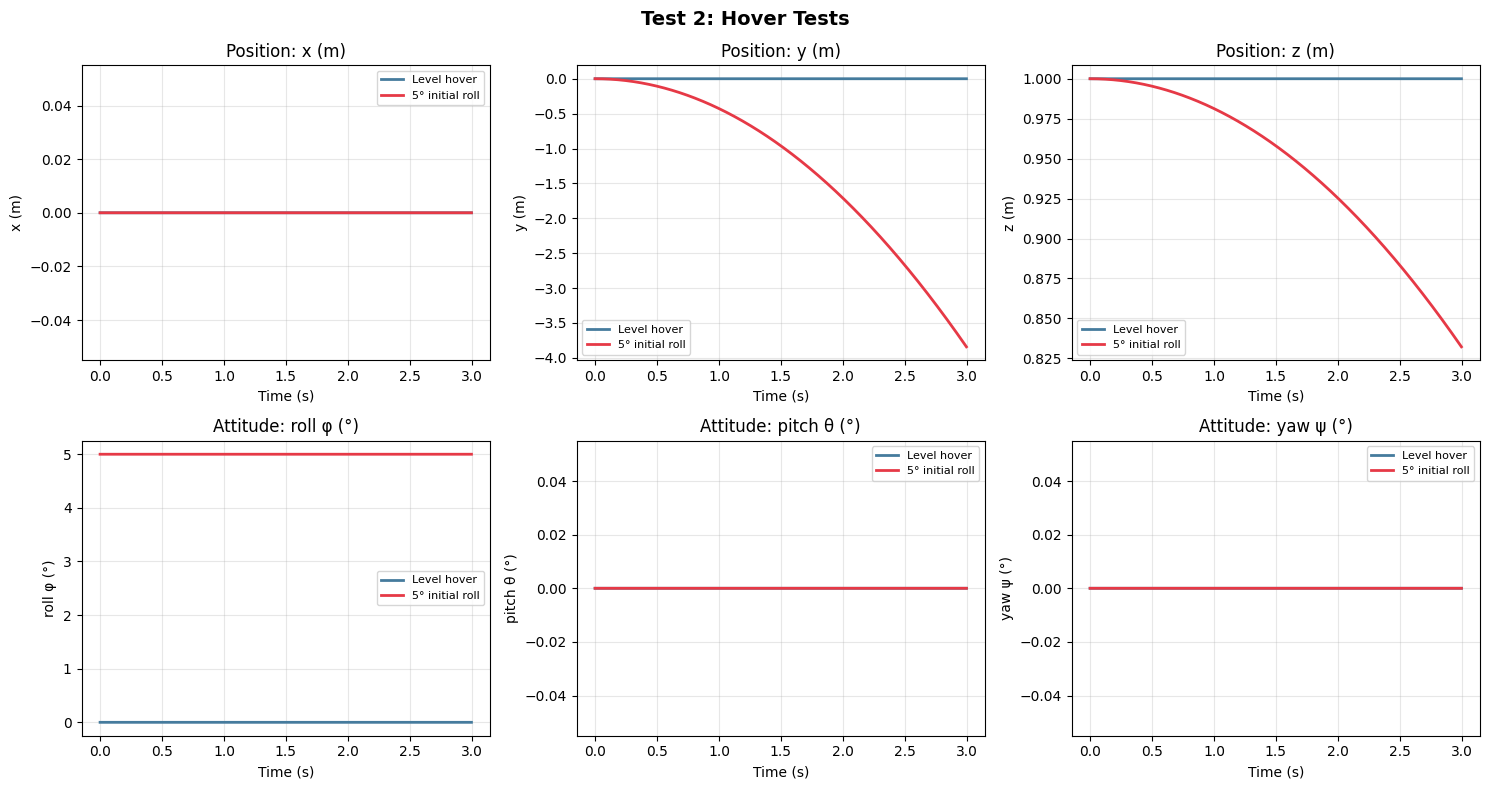

Level hover z-drift after 3.0s: 0.00e+00 m  (should be ~0)
5° roll case — x drift after 3.0s: 0.000 m  (expected: positive, translational coupling)


In [ ]:
# ── Case A: Perfect hover (level) ───────────────────────────────────────────
t_end  = 3.0
t_span = np.arange(0, t_end, dt)

quad.reset()
rotors_hover = np.full(4, omega_hover)

states_hover = [quad.state.copy()]
for _ in t_span[1:]:
    quad.step(rotors_hover, dt)
    states_hover.append(quad.state.copy())
states_hover = np.array(states_hover)

# ── Case B: Hover with 5° initial roll ──────────────────────────────────────
init_state_tilted = np.zeros(12)
init_state_tilted[2] = 1.0
init_state_tilted[6] = np.radians(5)   # 5° roll

quad.reset(init_state_tilted)

states_tilted = [quad.state.copy()]
for _ in t_span[1:]:
    quad.step(rotors_hover, dt)
    states_tilted.append(quad.state.copy())
states_tilted = np.array(states_tilted)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Test 2: Hover Tests', fontsize=14, fontweight='bold')

labels_pos   = ['x (m)', 'y (m)', 'z (m)']
labels_angle = ['roll φ (°)', 'pitch θ (°)', 'yaw ψ (°)']

for i in range(3):
    ax = axes[0, i]
    ax.plot(t_span, states_hover[:, i],   color='#457b9d', lw=2,   label='Level hover')
    ax.plot(t_span, states_tilted[:, i],  color='#e63946', lw=2,   label='5° initial roll')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(labels_pos[i])
    ax.set_title(f'Position: {labels_pos[i]}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for i in range(3):
    ax = axes[1, i]
    ax.plot(t_span, np.degrees(states_hover[:, 6+i]),  color='#457b9d', lw=2,  label='Level hover')
    ax.plot(t_span, np.degrees(states_tilted[:, 6+i]), color='#e63946', lw=2,  label='5° initial roll')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(labels_angle[i])
    ax.set_title(f'Attitude: {labels_angle[i]}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hover_test.png', dpi=150, bbox_inches='tight')
plt.show()

z_drift = np.abs(states_hover[-1, 2] - 1.0)
print(f"Level hover z-drift after {t_end}s: {z_drift:.2e} m  (should be ~0)")
print(f"5° roll case — x drift after {t_end}s: {states_tilted[-1,0]:.3f} m  (expected: positive, translational coupling)")

## 7. 3D Trajectory Visualization

Let's visualize the open-loop response to a gentle asymmetric rotor command — one rotor slightly faster than the others. This creates a real-looking trajectory with coupled roll, pitch, and translation.

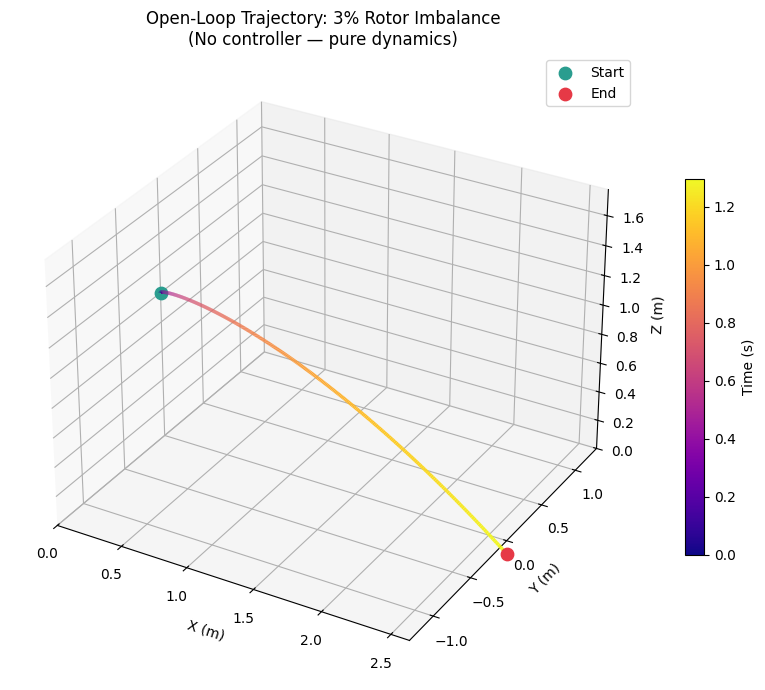

Simulation ran for 1.30s (650 steps)
Final position: x=2.632m, y=0.015m, z=-0.104m
Final attitude: roll=178.9°, pitch=51.3°


In [ ]:
def run_simulation(quad, rotor_cmd_fn, t_end=4.0, dt=0.002, disturbance_fn=None):
    """
    Generic simulation runner.
    rotor_cmd_fn(t, state) -> (4,) array of rotor speeds
    disturbance_fn(t)      -> (3,) force vector or None
    """
    t_span = np.arange(0, t_end, dt)
    states = [quad.state.copy()]
    times  = [0.0]

    for t in t_span[1:]:
        cmd  = rotor_cmd_fn(t, quad.state)
        dist = disturbance_fn(t) if disturbance_fn else None
        quad.step(cmd, dt, disturbance=dist)
        states.append(quad.state.copy())
        times.append(t)

        # Safety: stop if drone hits the ground or goes too high
        if quad.state[2] < -0.1 or quad.state[2] > 20:
            break

    return np.array(times), np.array(states)


# ── Scenario: gentle open-loop spiral (imbalanced rotors) ───────────────────
def imbalanced_cmd(t, state):
    """Rotor 1 is 3% faster — creates persistent roll torque = spiral drift."""
    cmds = np.full(4, omega_hover)
    cmds[0] *= 1.03
    return cmds

quad.reset()
times_ol, states_ol = run_simulation(quad, imbalanced_cmd, t_end=2.5)

# ── 3D plot ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

x, y, z = states_ol[:, 0], states_ol[:, 1], states_ol[:, 2]

# Color by time
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection

points  = np.array([x, y, z]).T.reshape(-1, 1, 3)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
norm    = plt.Normalize(times_ol.min(), times_ol.max())
lc      = Line3DCollection(segments, cmap='plasma', norm=norm, linewidth=2.5)
lc.set_array(times_ol[:-1])
ax.add_collection3d(lc)

# Start / end markers
ax.scatter(*[x[0], y[0], z[0]],   color='#2a9d8f', s=80, zorder=5, label='Start')
ax.scatter(*[x[-1], y[-1], z[-1]], color='#e63946', s=80, zorder=5, label='End')

fig.colorbar(lc, ax=ax, label='Time (s)', shrink=0.6)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Open-Loop Trajectory: 3% Rotor Imbalance\n(No controller — pure dynamics)', fontsize=12)
ax.legend()

# Equal aspect trick for 3D
max_range = np.array([x.max()-x.min(), y.max()-y.min(), z.max()-z.min()]).max() / 2
mid_x, mid_y, mid_z = (x.max()+x.min())/2, (y.max()+y.min())/2, (z.max()+z.min())/2
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(max(0, mid_z - max_range), mid_z + max_range)

plt.tight_layout()
plt.savefig('open_loop_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Simulation ran for {times_ol[-1]:.2f}s ({len(times_ol)} steps)")
print(f"Final position: x={x[-1]:.3f}m, y={y[-1]:.3f}m, z={z[-1]:.3f}m")
print(f"Final attitude: roll={np.degrees(states_ol[-1,6]):.1f}°, "
      f"pitch={np.degrees(states_ol[-1,7]):.1f}°")